# **NOAA Mauna Loa Atmospheric CO₂ Time Series Analysis**

This analysis examines the **monthly mean atmospheric carbon dioxide CO₂ concentrations** recorded at the **National Oceanic and Atmospheric Administration (NOAA) Mauna Loa Observatory, Hawaii**, expressed as **mole fraction in parts per million (ppm)**. Mole fraction in parts per million means the proportion of CO₂ molecules in the air, expressed per one million molecules. 
- `For example:` **400 ppm CO₂** means approximately **400 out of every 1,000,000 air molecules are CO₂**. 

The dataset provides monthly observations beginning in **1958**. The `average` variable represents the observed monthly mean CO₂ concentration and will serve as the principal series for analysis.

The primary objective is to investigate the **long-term trend**, **seasonal behavior**, and **time-series properties** of atmospheric CO₂ concentrations. The analysis will first examine the raw CO₂ series before proceeding to **stationarity testing, differencing, seasonal adjustment, and time-series modeling**. After selecting the best-performing model, a **multi-month future forecast** will be generated together with **confidence intervals**. Model performance will then be evaluated using a **chronological holdout set**, comparing the forecasts against the actual observed CO₂ concentrations.

The overall aim is to demonstrate the **full workflow of a time-series analysis**, from exploratory analysis and data preparation through model selection & validation, forecasting, and out-of-sample evaluation.

## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1958-03-01 00:00:00 to 2024-07-01 00:00:00
Number of observations: 797

Holdout data:
2024-08-01 00:00:00 to 2026-07-01 00:00:00
Number of observations: 24


## **2. Raw Series: Visual Inspection**
The raw monthly CO₂ series is plotted using the `average` concentration to identify its main time-series characteristics.

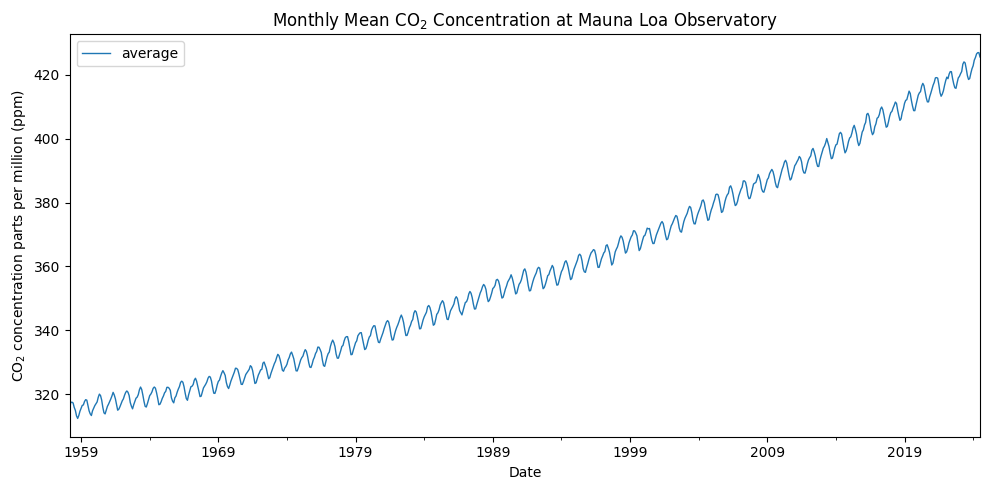

In [3]:
# Plot the raw series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly Mean CO$_2$ Concentration at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO$_2$ concentration parts per million (ppm)")
plt.tight_layout()
plt.show()

### Raw Series Plot Observation
- The plot shows two dominant features: a **strong long‑term upward trend** and a clear **recurring seasonal cycle**. 
- CO₂ concentrations increase from approximately **315 ppm in the late 1950s** to **over 420 ppm in recent years**, while exhibiting regular within-year fluctuations.
- The combination of trend and seasonality indicates that the mean and other statistical properties of the series change over time, suggesting that the raw series is **non-stationary**.
- These characteristics motivate the use of time-series methods capable of handling both **non-seasonal and seasonal dynamics**, such as seasonal decomposition and **SARIMA models**. 
- Formal stationarity checks will next be assessed using two complementary tests:
    - **Augmented Dickey–Fuller (ADF) Test**
        - `Null hypothesis:` the series contains a unit root and is non-stationary.
        - For the raw CO₂ series, we expect to **fail to reject the null hypothesis**.
    - **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test**
        - `Null hypothesis:` the series is stationary around a deterministic trend.
        - For the raw CO₂ series, we expect to **reject the null hypothesis**.
- Using both tests provides stronger evidence about the stationarity properties of the series before differencing and model development

### **2.1 Raw Series: ACF and PACF**
Before carrying out the `ADF` and `KPSS` stationarity tests, we examine the **Autocorrelation Function (`ACF`)** and **Partial Autocorrelation Function (`PACF`)** of the raw CO₂ series. The ACF measures the correlation between the CO₂ series and its previous values at different lags, while the PACF measures the correlation at each lag after accounting for the effects of shorter lags. For monthly data, particular attention is given to **lag 12 and its multiples**, which can reveal the annual seasonal structure.

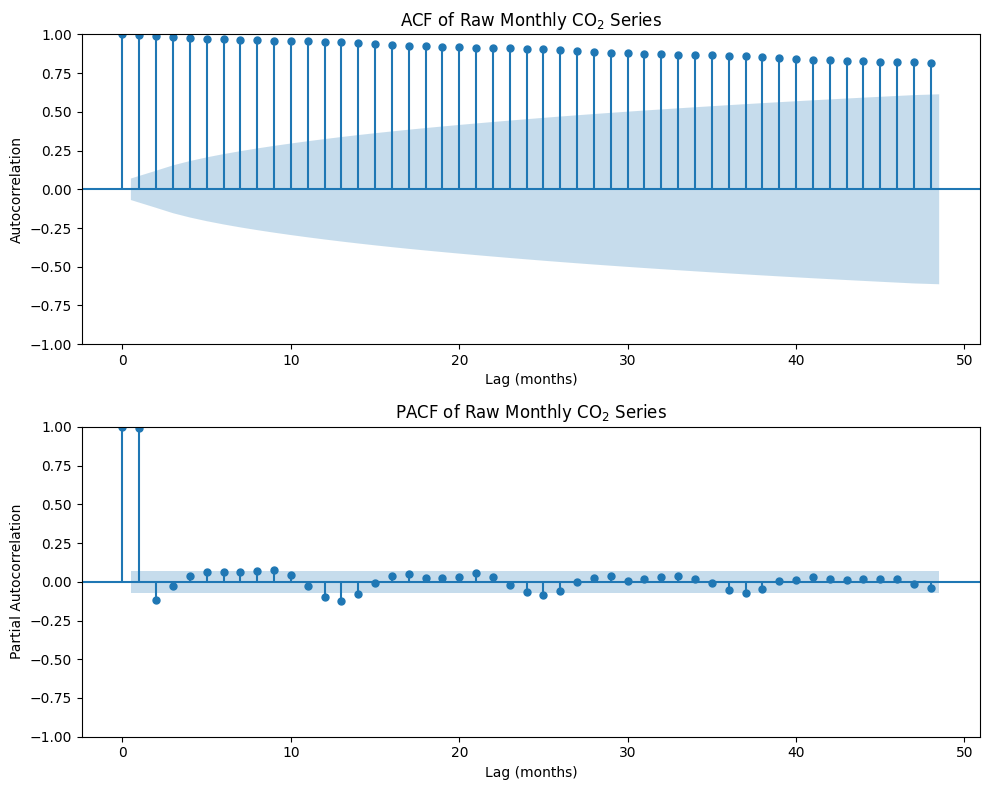

In [4]:
# Plot the ACF and PACF of the raw series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(
    train["average"].dropna(),
    lags=48,
    ax=axes[0],
    alpha=0.05
)
axes[0].set_title("ACF of Raw Monthly CO$_2$ Series")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    train["average"].dropna(),
    lags=48,
    ax=axes[1],
    alpha=0.05,
    method="ywm"
)
axes[1].set_title("PACF of Raw Monthly CO$_2$ Series")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

#### Raw Series: ACF and PACF Observations
- The ACF remains strongly positive across many lags, indicating substantial persistence in the raw CO₂ series. The slow decay of the ACF is a characteristic of a **non-stationary series** with a **strong underlying trend**.
- Overall, the ACF and PACF provide additional visual evidence that the raw CO₂ series contains **strong temporal dependence**, **trend**, and **seasonality**.

### **2.2 Stationarity Tests: ADF and KPSS**
To formally assess the stationarity of the raw CO₂ series, both the `ADF`and `KPSS` tests are applied. The tests use complementary null hypotheses, providing stronger evidence when they lead to the same conclusion.

**ADF Test**
- `Null hypothesis` ($H_0$): The series has a unit root and is **non-stationary**.
- `Alternative hypothesis` ($H_1$): The series is **stationary**.
- **Decision rule:** Reject $H_0$ when the **p-value < 0.05**.

**KPSS Test**
- `Null hypothesis` ($H_0$): The series is **stationary**.
- `Alternative hypothesis` ($H_1$): The series is **non-stationary**
- **Decision rule:** Reject $H_0$ when the **p-value < 0.05**.

A significance level of **5\% ($\alpha = 0.05$)** is used throughout the analysis.

In [5]:
# ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(train["average"])

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(train["average"], regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 6.2373
p-value       : 1.0000
Lags Used     : 21
Observations  : 775

Critical Values:
   1%: -3.4388
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 4.2289
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2408/4057016753.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train["average"], regression='c', nlags='auto')


#### Raw Series: Stationarity Test Results
##### 1. ADF Test
  - Test statistic: `ADF = 6.2373`
  - p‑value: `p = 1.0000`
  - Critical values:
    - 1%: `-3.4388` 
    - 5%: `-2.8653`
    - 10%: `-2.5688`

Since the p-value is much greater than 0.05 and the test statistic is far above all critical value, we **fail to reject the null hypothesis**.

**Interpretation:** The ADF test provides strong evidence that the raw CO₂ series is **non-stationary**.

##### 2. KPSS Test
- Test statistic: `KPSS = 4.2289`  
- p‑value: `p = 0.0100` (actual p‑value even smaller; outside lookup table range)  
- Critical values:  
  - 1%: `0.7390`  
  - 2.5%: `0.5740`  
  - 5%: `0.4630`  
  - 10%: `0.3470`

Since the KPSS statistic is substantially greater than all critical values and the p-value is below 0.05, we **reject the null hypothesis of stationarity**.

**Interpretation:** The KPSS test also indicates that the raw CO₂ series is **non-stationary**.

**Note:** The `InterpolationWarning` indicates that the KPSS statistic is outside the range covered by the p-value lookup table. Therefore, `0.0100` should be interpreted as the smallest reported table value; the **actual p-value is smaller than 0.0100**.

---

#### Combined Interpretation

Both tests independently indicate that the raw CO₂ series is **non-stationary**. This is consistent with the strong upward trend and recurring seasonal structure observed in the previous plots.

The series therefore requires further transformation before fitting models that assume stationarity. The next stage is to investigate **differencing and seasonal differencing**, followed by re-examination of the ACF, PACF, ADF, and KPSS statistics.

## **3. Differencing the CO₂ Raw Series**
To obtain a stationary series suitable for time-series modelling, differencing is considered. Two common approaches are **absolute (regular) differencing** and **log differencing**. Regular differencing measures the absolute change in CO₂ concentration;

$$\Delta CO_{2,t} = CO_{2,t} - CO_{2,t-1}$$

whereas log differencing measures the proportional change:
$$\Delta \log(CO_{2,t}) = \log(CO_{2,t}) - \log(CO_{2,t-1}) = \log\left(\frac {CO_{2,t}}{CO_{2,t-1}}\right)$$

Because the CO₂ series is measured in **ppm** and the focus here is on changes in concentration in physical units rather than percentage growth, **absolute differencing is used**. Log differencing would instead be appropriate when the primary interest is in relative or percentage changes.


### **3.1 Regular First Differencing**

The first step is to apply **regular first differencing** with a **lag of 1** to the raw monthly CO₂ concentration series. Regular differencing removes changes in the series associated with the long-term trend and transforms the analysis from CO₂ concentration levels to **month-to-month changes in concentration**.

The resulting series is plotted below to assess visually whether the long-term upward trend has been removed and to determine whether any systematic pattern remains.


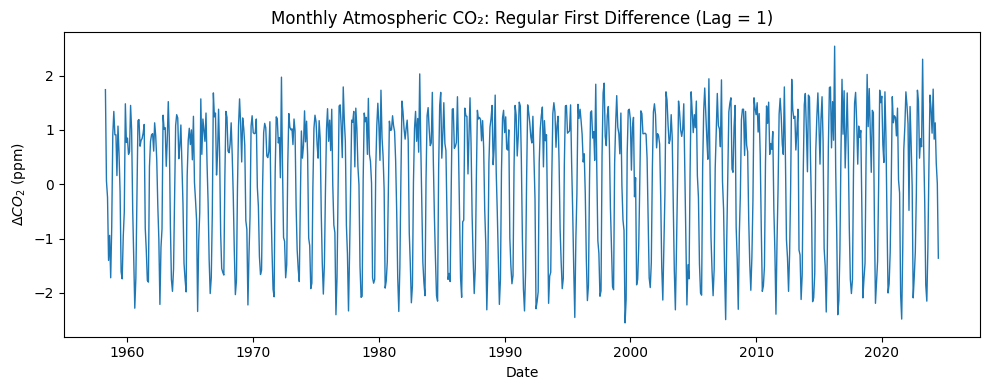

In [16]:
# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Monthly Atmospheric CO₂: Regular First Difference (Lag = 1)")
plt.xlabel("Date")
plt.ylabel(r"$\Delta CO_2$ (ppm)")
plt.tight_layout()
plt.show()

#### Regular First Differencing Observations

Regular first differencing substantially removes the long-term upward trend evident in the raw CO₂ series. The transformed series now fluctuates around a relatively stable mean rather than exhibiting a persistent increase over time.

However, a pronounced **seasonal oscillation remains visible**. The repeated pattern in the month-to-month changes indicates that regular differencing has removed much of the non-seasonal trend but has not eliminated the annual seasonal component. This remaining seasonality is investigated using the ACF and PACF below.


### **3.2 ACF and PACF of the Regularly Differenced CO₂ Series**

To further investigate the dependence structure remaining after regular differencing, the **ACF** and **PACF** are examined. For monthly data, particular attention is given to lags **12, 24, 36, and 48**, which correspond to one, two, three, and four-year intervals. Pronounced correlations at these lags would provide evidence of an annual seasonal cycle.


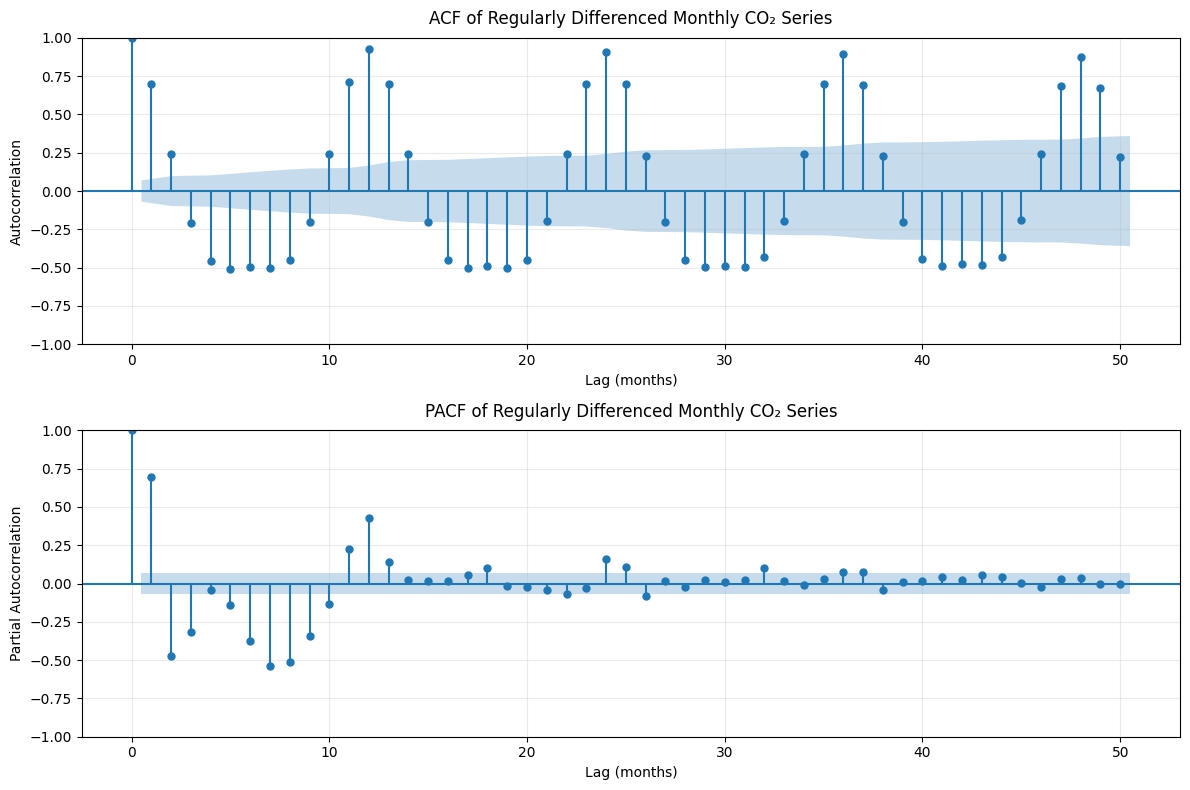

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Regularly differenced series
diff_regular = train["average"].diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- ACF ---
plot_acf(diff_regular,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title(
    "ACF of Regularly Differenced Monthly CO₂ Series",
    fontsize=12,
    pad=10
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_regular,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title(
    "PACF of Regularly Differenced Monthly CO₂ Series",
    fontsize=12,
    pad=10
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF: Seasonal Dependence

The ACF of the regularly differenced series exhibits pronounced positive autocorrelation at approximately **12-month intervals**, with additional peaks at lags 24, 36, and 48. This repeating structure is characteristic of a strong **annual seasonal cycle** in atmospheric CO₂ concentrations.

The PACF also shows significant dependence at short and seasonal lags, confirming that temporal dependence remains after regular differencing. Thus, although regular differencing has effectively addressed the long-term trend, it has **not removed the annual seasonal structure**. The strong seasonal peaks at lags 12, 24, 36, and 48 therefore indicate that a **seasonal differencing component with a period of 12 months** is appropriate to investigate further.


### **3.3 Monthly Distribution of the Regularly Differenced CO₂ Series**

The seasonal structure remaining after regular first differencing can be examined more directly by grouping the differenced CO₂ observations by calendar month. The boxplot below shows the distribution of month-to-month changes in atmospheric CO₂ concentration for each month of the year.

Because the series has been regularly differenced, positive values indicate that atmospheric CO₂ increased relative to the previous month, while negative values indicate a month-to-month decrease. When the distribution of the differences varies systematically across calendar months, this provides visual evidence of **seasonality in the rate of change of atmospheric CO₂**.


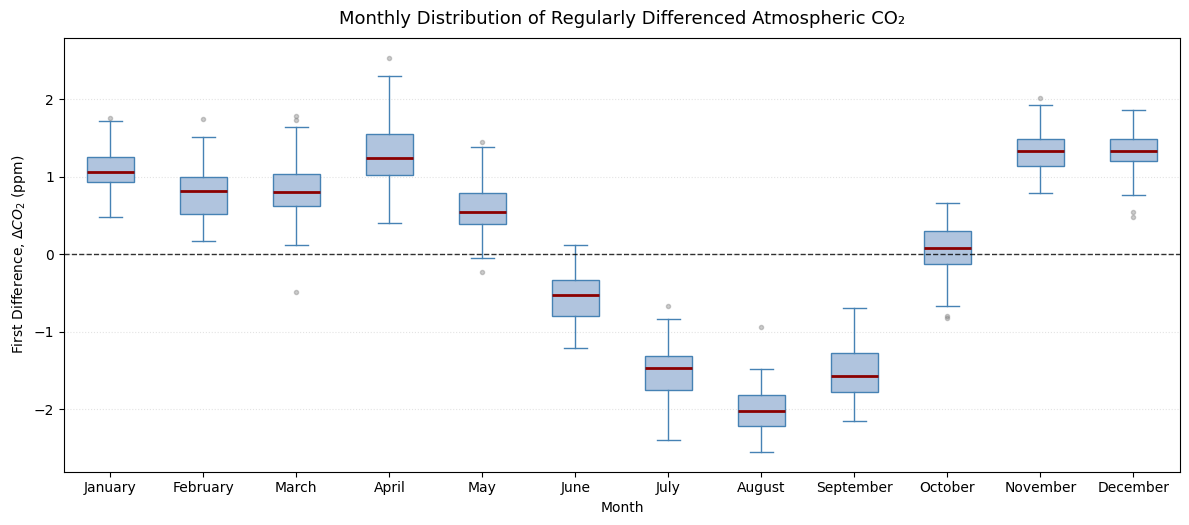

In [24]:
import calendar
# Prepare regularly differenced CO2 series
co2_diff = train[["diff_regular"]].dropna().copy()

# Extract calendar month
co2_diff["Month"] = co2_diff.index.month_name()

# Preserve chronological order
month_order = list(calendar.month_name[1:])
co2_diff["Month"] = pd.Categorical(co2_diff["Month"],
    categories=month_order,
    ordered=True
)

# Boxplot
fig, ax = plt.subplots(figsize=(12, 5.5))
co2_diff.boxplot(column="diff_regular",by="Month",ax=ax,grid=False,patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue",color="steelblue"),
    medianprops=dict(color="darkred",linewidth=2),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue"),
    flierprops=dict(marker="o",markersize=3,markerfacecolor="gray",markeredgecolor="gray",alpha=0.4)
)

# Remove pandas automatic title
plt.suptitle("")
# Zero line: very important for interpreting increases vs decreases
ax.axhline(0,color="black",linestyle="--",linewidth=1,alpha=0.8)

ax.set_title("Monthly Distribution of Regularly Differenced Atmospheric CO₂",
    fontsize=13,pad=10)

ax.set_xlabel("Month")
ax.set_ylabel(r"First Difference, $\Delta CO_2$ (ppm)")

ax.grid(axis="y",linestyle=":",alpha=0.35)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Monthly Seasonal Pattern in CO₂ Changes
The boxplot reveals a clear seasonal structure in the **month-to-month changes** in atmospheric CO₂ concentration. The distributions of the first differences vary systematically across the calendar year rather than being centered around the same value for all months.

In particular, the summer months, especially **July, August, and September**, show substantially more negative first differences. A negative value means; $\Delta CO_{2,t} < 0,$ or equivalently, $CO_{2,t} < CO_{2,t-1}.$ Thus, the large negative values during these months indicate that atmospheric CO₂ concentration commonly **decreases from the preceding month** during this part of the year.

#### What Causes the Monthly Seasonal Pattern?

This seasonal behaviour pattern is physically consistent with the dominant influence of the terrestrial biosphere on atmospheric CO₂. The seasonal CO₂ cycle is particularly strong because a large proportion of the Earth's land area and vegetation is located in the **Northern Hemisphere**. During Northern Hemisphere spring and summer, increased photosynthetic activity removes CO₂ from the atmosphere, while during autumn and winter, reduced photosynthesis and continued respiration & decomposition return more CO₂ to the atmosphere. This produces a recurring annual oscillation in atmospheric CO₂ concentrations.

Conversely, during the Northern Hemisphere winter, photosynthetic CO₂ uptake is substantially reduced, while energy demand for heating generally increases. The associated combustion of fossil fuels for heating and electricity generation, together with continued transportation and other human activities, adds CO₂ to the atmosphere during a period when natural terrestrial uptake is relatively weak. The combination of these factors produces a recurring annual oscillation and upward trend in atmospheric CO₂ concentrations.

#### Why does the Southern Hemisphere not cancel the Northern Hemisphere cycle?

Although the Southern Hemisphere experiences its growing season while the Northern Hemisphere is in winter, its influence is considerably weaker. The key reason is the strong **asymmetry in land and vegetation distribution** between the two hemispheres. The Northern Hemisphere contains substantially more land and terrestrial vegetation, whereas the Southern Hemisphere is dominated by oceans.

Consequently, the seasonal uptake and release of CO₂ by Northern Hemisphere terrestrial ecosystems is much larger than the corresponding seasonal cycle in the Southern Hemisphere. The Southern Hemisphere therefore partially offsets the Northern Hemisphere signal, but not enough to cancel it. Therefore, the resulting global atmospheric CO₂ record retains a pronounced annual cycle dominated by the Northern Hemisphere biosphere.

Finally, the monthly boxplot provides a clear visual explanation for the seasonal peaks observed in the ACF: the month-to-month change in atmospheric CO₂ is itself strongly dependent on the **time of year**. This confirms that regular differencing has removed much of the long-term trend but has **not removed the annual seasonal component**, motivating the application of seasonal differencing with a period of \(s=12\).

### **3.4 Seasonal and Regular Differencing**

Since regular differencing removes the long-term trend but leaves a pronounced annual seasonal pattern, we next apply **seasonal differencing** with a period of $s=12$, together with the regular first difference.

The combined transformation is:
$$(1-B)(1-B^{12})CO_{2,t},$$

where $B$ is the backshift operator. Equivalently;
$$\Delta_1\Delta_{12}CO_{2,t}=CO_{2,t}-CO_{2,t-1}-CO_{2,t-12}+CO_{2,t-13}.$$

This transformation is intended to remove both the **long-term non-seasonal trend** and the **annual seasonal component** from the monthly CO₂ series.


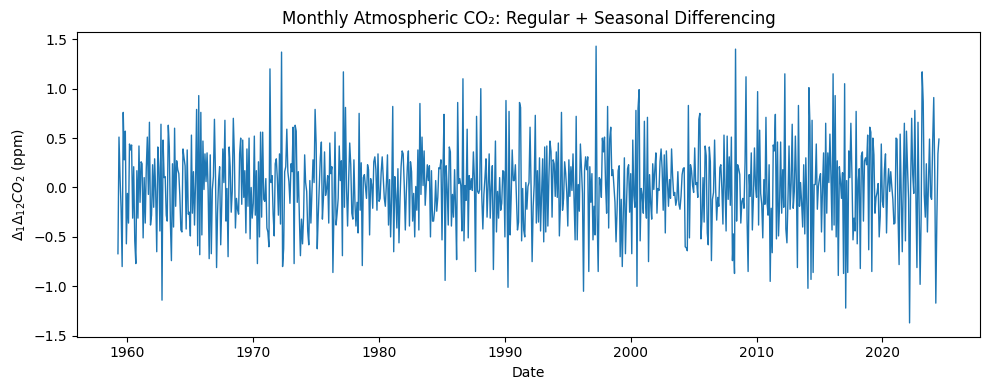

In [27]:
# --- Combined differencing: seasonal + regular ---
train["diff_both"] = train["average"].diff(12).diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_both"], linewidth=1)
plt.title("Monthly Atmospheric CO₂: Regular + Seasonal Differencing")
plt.xlabel("Date")
plt.ylabel(r"$\Delta_1\Delta_{12} CO_2$ (ppm)")
plt.tight_layout()
plt.show()

#### Combined Differencing: Observations
After applying both regular and seasonal differencing, the long-term upward trend is no longer apparent, and the pronounced annual oscillation observed in the regularly differenced series is substantially reduced.

The resulting series fluctuates around a relatively stable level, suggesting that the combined transformation has removed the major sources of non-stationarity associated with the trend and annual seasonality. The ACF and PACF of the transformed series are examined next to determine whether substantial autocorrelation remains.

### **3.5 ACF and PACF of the Seasonally and Regularly Differenced CO₂ Series**

The ACF and PACF are now examined for the series after applying both seasonal differencing (`s = 12`) and regular differencing (`lag = 1`). At this stage, the objective is to determine whether the dominant trend and seasonal dependence have been removed and to identify any remaining short-term or seasonal autocorrelation that may be relevant for subsequent **SARIMA model** specification.

- The **ACF** helps in identifying the **MA(q)** component by showing how many significant autocorrelation spikes remain after differencing.
- The **PACF** helps identify the **AR(p)** component by showing how many partial autocorrelation spikes remain.
- Seasonal spikes at lag 12 (and multiples) often indicate the need for seasonal AR or MA terms in a SARIMA model.
- Together, the ACF and PACF plots guide the selection of `(p, d, q)` and `(P, D, Q)` for SARIMA.

We will use these plots to propose candidate SARIMA models


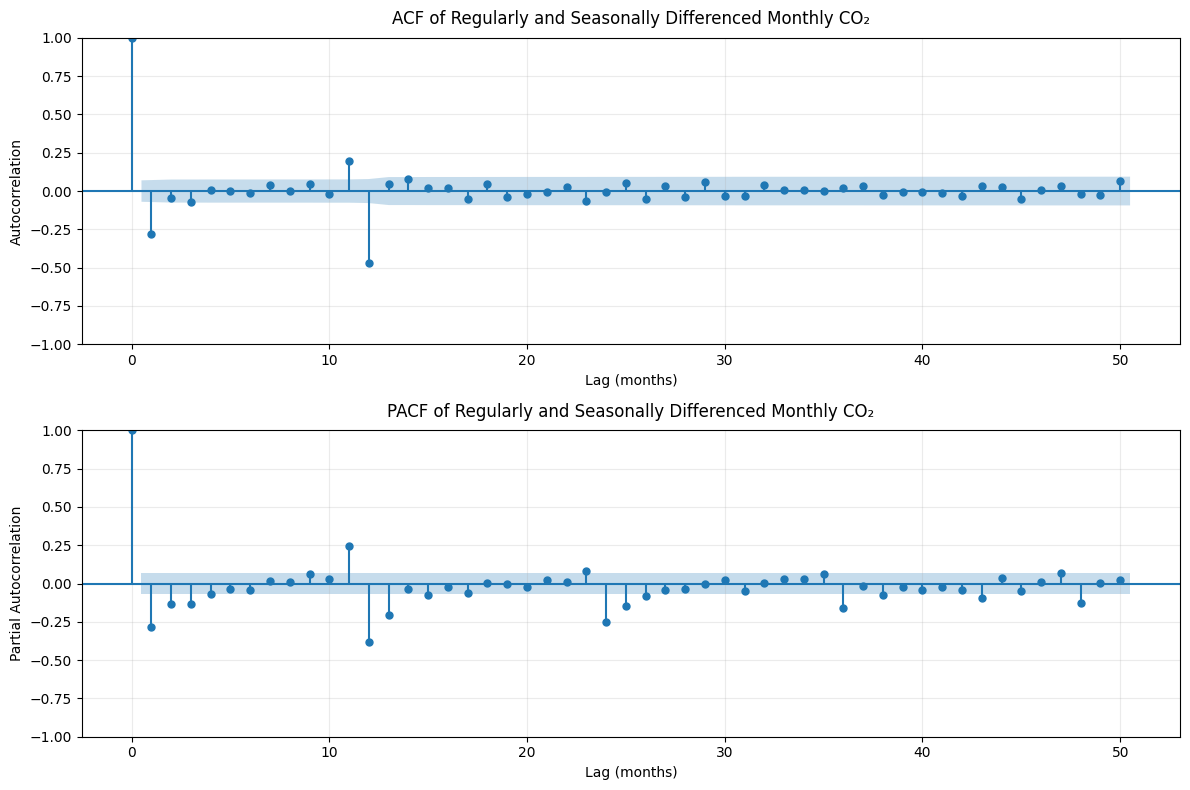

In [29]:
# Combined differenced series
diff_both = (train["average"].diff(12).diff(1).dropna())

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- ACF ---
plot_acf(diff_both,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title("ACF of Regularly and Seasonally Differenced Monthly CO₂",fontsize=12,pad=10)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_both,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title("PACF of Regularly and Seasonally Differenced Monthly CO₂",fontsize=12,pad=10)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF After Combined Differencing: Observations

Following the application of both regular and seasonal differencing, the strong long-term dependence and pronounced annual seasonal pattern observed previously are substantially reduced. 

**ACF:** The ACF shows a small significant negative correlation at lag 1, indicating short-term dependence between consecutive monthly changes. A strong negative spike at lag 12, provides a clear evidence of remaining **annual seasonal dependence**. The absence of a long, slowly decaying ACF suggests that the major non-stationary trend has been removed.

**PACF:** The PACF shows small significant negative spikes at lags 1, 2, and 3, suggesting a possible **non-seasonal AR structure**. Strong dependence is also observed around lag 12, with additional seasonal-lag effects at 24, 36, and 48. These repeated seasonal features indicate that the transformed series still contains structured annual dependence that may be captured by a **seasonal AR component**.

Overall, the ACF and PACF indicate that the combined differencing has substantially reduced the trend and seasonal non-stationarity, while leaving short-term and seasonal dependence that can be modelled using SARIMA.

#### Implications for SARIMA Model Identification

Based on the ACF and PACF, a reasonable starting candidate is $(p,d,q)=(2,1,1)$ for the non-seasonal component and $(P,D,Q)_{12}=(0,1,1)_{12}$ for the seasonal component. This gives the candidate model

$$\boxed{\mathrm{SARIMA}(2,1,0)\times(0,1,1)_{12}}$$

This should be regarded as a **candidate rather than a final model**. Nearby specifications, such as $\mathrm{SARIMA}(3,1,1)\times(0,1,2)_{12}$ and $\mathrm{SARIMA}(1,1,2)\times(1,1,1)_{12},$ will subsequently be compared using AIC/BIC and, importantly, residual diagnostics to determine whether the remaining autocorrelation has been adequately captured.

Next step:  
Re‑run ADF and KPSS test to statistically confirm stationarity before fitting SARIMA models.

### **3.6 Formal Stationarity Tests: ADF and KPSS**

Although the time plot, ACF, and PACF suggest that the combined differencing has removed the major trend and seasonal structure, stationarity is formally assessed using the **ADF** and **KPSS** tests. Ideally, evidence of stationarity is obtained when the ADF test rejects its null hypothesis while the KPSS test fails to reject its null hypothesis.


In [30]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -11.2895
p-value       : 0.0000
Lags Used     : 12
Observations  : 771

Critical Values:
   1%: -3.4389
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 0.0456
p-value        : 0.1000
Lags Used      : 30

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2408/1961808396.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')


#### ADF and KPSS Stationarity Tests: Results and Interpretation

The ADF and KPSS test results are:

| Test | Statistic | p-value | Interpretation |
|---|---:|---:|---|
| ADF | $-11.2895$ | $<0.001$ | Reject non-stationarity |
| KPSS | $0.0456$ | $>0.10$ | Fail to reject stationarity |

For the **ADF test**, the test statistic of \(-11.2895\) is substantially more negative than all reported critical values, including the 1% critical value of \(-3.4389\). The p-value is effectively zero, providing very strong evidence against the null hypothesis of a unit root. We therefore reject the hypothesis that the differenced series is non-stationary.

For the **KPSS test**, the statistic of \(0.0456\) is far below the 10% critical value of \(0.3470\). The reported p-value is \(0.1000\), with an interpolation warning indicating that the actual p-value is **greater than 0.10**. Therefore, there is no evidence to reject the null hypothesis of stationarity.

Taken together, the two tests provide **consistent and strong evidence that the combined regularly and seasonally differenced CO₂ series is stationary**. This confirms the visual evidence from the time plot, ACF, and PACF: the long-term trend and the dominant annual seasonal non-stationarity have been effectively removed by applying one regular difference and one seasonal difference.

Thus, for the subsequent SARIMA analysis, the differencing orders are supported by the data as

$$d=1,\qquad D=1,\qquad s=12.$$

The remaining structure visible in the ACF and PACF can therefore be interpreted primarily as **stationary temporal dependence**, rather than as evidence of an unresolved trend or seasonal unit root. This remaining dependence will be used to identify and compare appropriate non-seasonal and seasonal AR/MA components.


## **4 SARIMA Model Specification and Selection**

The preceding analysis established that the monthly CO₂ series contains both a long-term trend and a strong annual seasonal pattern. Regular and seasonal differencing were therefore applied, and the ADF and KPSS tests provided strong evidence that the resulting series is stationary.

We now model the original CO₂ series using a **Seasonal Autoregressive Integrated Moving Average (SARIMA)** model. The general specification is $\mathrm{SARIMA}(p,d,q)\times(P,D,Q)_{s},$ where $p$, $q$ describe the non-seasonal autoregressive and moving-average components, $P$, $Q$ describe their seasonal counterparts, $d$ is the order of regular differencing, $D$ is the order of seasonal differencing, and $s$ is the seasonal period.

From the preceding differencing and stationarity analysis, the integration orders are retained as 

$$d=1,\qquad D=1,\qquad s=12.$$

The ACF and PACF provide guidance for selecting the remaining AR and MA orders. However, these plots are used to identify **candidate models rather than a single definitive specification**. Several plausible SARIMA models are therefore fitted and compared.

Model selection is based primarily on:

- **AIC (Akaike Information Criterion):** balances model fit against model complexity, with lower values preferred.
- **BIC (Bayesian Information Criterion):** applies a stronger penalty for additional parameters and therefore favours more parsimonious models (a models that explains the important structure in the data using as few parameters as reasonably necessary).
- **Residual diagnostics:** a well-specified model should leave residuals that behave approximately like white noise, with no substantial remaining autocorrelation or systematic structure.
- **Parameter significance:** estimated AR and MA parameters should generally provide meaningful contributions to the model.
- **Residual variance and stability:** the residuals should show approximately constant variance without systematic changes over time.

Importantly, the model is fitted to the **raw CO₂ concentration series**, rather than directly to the already differenced series. The values $d=1$ and $D=1$ tell the SARIMA model how to transform the raw series internally before modelling its stationary dynamics. This allows the model to represent the original CO₂ process while accounting explicitly for the trend and annual seasonal integration. The SARIMAX implementation supports this integrated formulation directly. 

Finally, residual **normality** is assessed as part of the diagnostics. Ideally, residuals should be approximately normally distributed because the standard Gaussian likelihood framework assumes normally distributed innovations, and approximate normality supports conventional statistical inference and forecast intervals. However, perfect normality is not required for a model to be useful; the more fundamental requirement for an adequate time-series model is that the residuals are approximately **uncorrelated (white noise)** and show no important systematic structure.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Raw series
y = train["average"]

# Fit SARIMA(p,1,q)x(P,1,Q,12)
model = SARIMAX(
    y,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

print(results.summary())


                                        SARIMAX Results                                        
Dep. Variable:                                 average   No. Observations:                  797
Model:             SARIMAX(1, 1, 1)x(0, 1, [1, 2], 12)   Log Likelihood                -199.806
Date:                                 Wed, 26 Aug 2026   AIC                            409.612
Time:                                         12:46:27   BIC                            432.766
Sample:                                     03-01-1958   HQIC                           418.529
                                          - 07-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2176      0.084      2.604      0.009       0.054       0

### Results of the Selected SARIMA Model

The selected $\mathrm{SARIMA}(1,1,1)\times(0,1,2)_{12}$ model was obtained after comparing several candidate specifications. The final model combines a non-seasonal AR(1) and MA(1) component with two seasonal MA terms at lags 12 and 24, while retaining the regular and seasonal differencing established in the previous analysis.

The model has an **AIC of 409.612**, a **BIC of 432.766**, and a **log-likelihood of -199.806**. These information criteria indicate the overall balance between goodness of fit and model complexity and were considered when comparing the candidate models.

The estimated non-seasonal AR(1) coefficient is $\hat{\phi}_1 = 0.2176,$ with a p-value of $0.009$, indicating statistically significant short-term autoregressive dependence.

The non-seasonal MA(1) coefficient is $\hat{\theta}_1 = -0.5714,$ with $p<0.001$, indicating a strong and statistically significant moving-average component.

For the seasonal component, the MA term at lag 12 is $\hat{\Theta}_1 = -0.8694,$ with $p<0.001$. This is highly significant and indicates a strong dependence associated with the annual seasonal cycle identified earlier in the ACF and PACF analysis.

The second seasonal MA term at lag 24, however, has an estimated coefficient of only $\hat{\Theta}_2 = 0.0007$ with $p=0.985$. This parameter is clearly not statistically significant and contributes very little to the model. Nevertheless, the specification was retained here because it formed part of the model selected during the candidate-model comparison; its redundancy should be considered when evaluating whether a more parsimonious alternative provides comparable or better performance.

Overall, the parameter estimates indicate that the model successfully captures both the **short-term dependence** and the **strong annual seasonal dynamics** identified earlier in the analysis.


### **4.1 Residual Diagnostics**

After fitting the SARIMA model, the residuals are examined to determine whether the model has successfully captured the systematic structure in the CO₂ series.

For a well-specified time-series model, the residuals should behave approximately as **white noise**. In particular, we look for:

- no remaining trend or systematic pattern in the residual time series;
- no significant autocorrelation in the residual ACF;
- approximately constant variance over time;
- an approximately symmetric and reasonably bell-shaped residual distribution;
- approximate agreement with a Normal distribution in the Q-Q plot.

The most important requirement is the absence of **remaining serial correlation**. If substantial autocorrelation remains, the SARIMA model has failed to capture some predictable structure in the data.

Normality is also assessed because the model is estimated using a Gaussian likelihood framework. Approximately normal innovations make the conventional likelihood-based inference and forecast intervals more appropriate. However, moderate departures from normality are generally less concerning than substantial residual autocorrelation or changing variance.


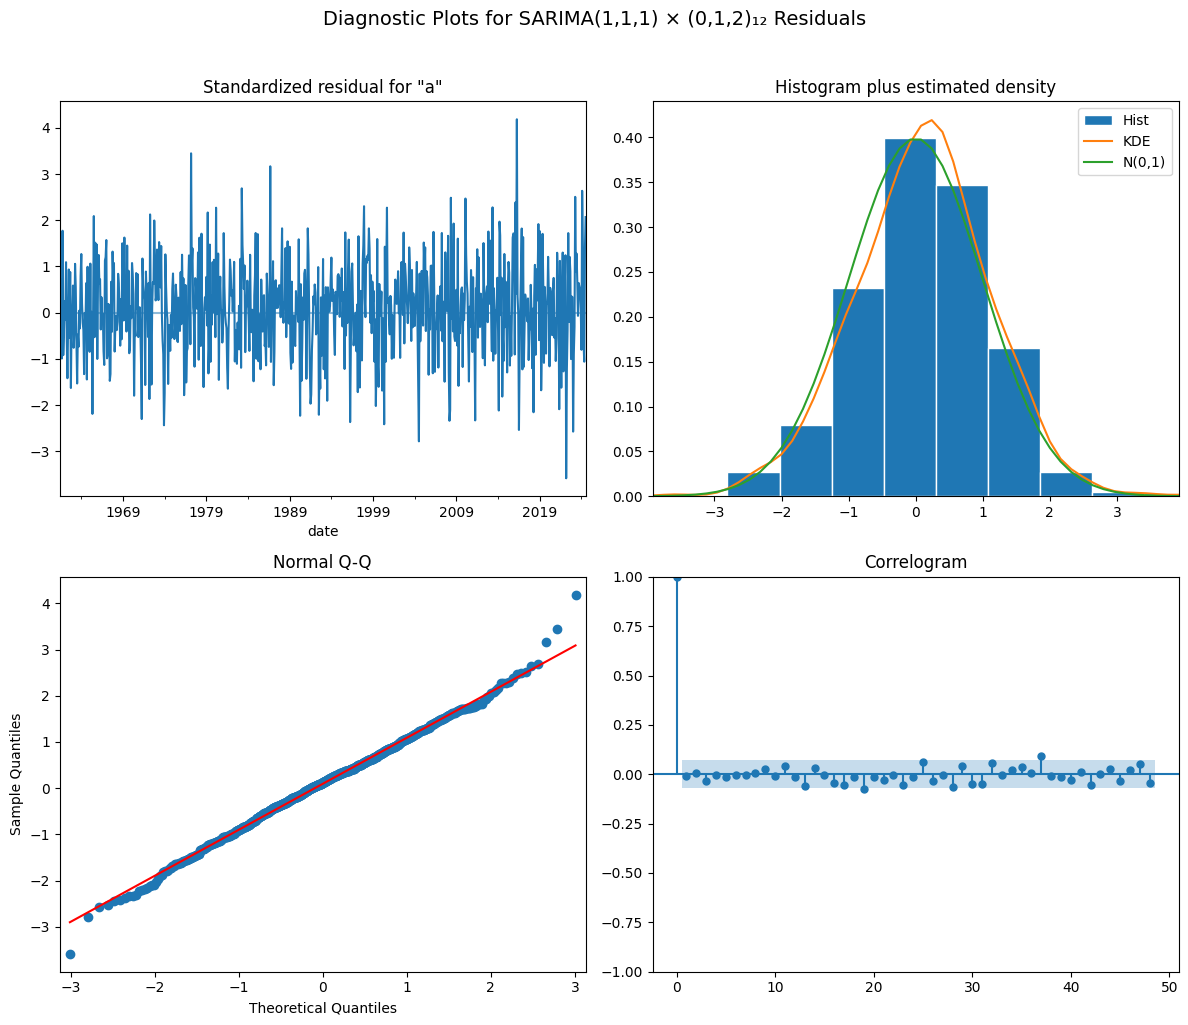

In [33]:
# --- SARIMA residual diagnostics ---

fig = results.plot_diagnostics(
    lags=48,
    figsize=(12, 10)
)

fig.suptitle(
    "Diagnostic Plots for SARIMA(1,1,1) × (0,1,2)₁₂ Residuals",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


### **4.2 Residual Diagnostics and Model Adequacy**

After fitting the SARIMA model, the next step is to examine its **residuals**. The residuals represent the part of the CO₂ series that remains unexplained by the model. A well-specified SARIMA model should leave residuals that behave approximately like **white noise**: they should contain little systematic temporal structure, have approximately constant variance, and ideally be reasonably close to normally distributed.

Several diagnostic checks are therefore used to evaluate whether the selected model has adequately captured the structure identified earlier.

#### **1. White-Noise Check: Ljung–Box Test**

The **Ljung–Box test** examines whether the residuals contain significant autocorrelation across a set of lags. Its null hypothesis is

$H_0:
\text{There is no autocorrelation in the residuals up to the specified lag.}
$

while the alternative hypothesis is

$
H_1:
\text{There is significant autocorrelation in the residuals.}
$

For a well-specified time-series model, we ideally want to **fail to reject $H_0$**, meaning that no statistically significant autocorrelation remains.

For example,

$
p > 0.05
$

would provide no evidence against the white-noise assumption, whereas

$
p < 0.05
$

would indicate statistically significant residual autocorrelation.

Because the CO₂ series has a strong annual cycle, the Ljung–Box test is evaluated at several seasonal horizons, including **12, 24, 36, and 48 months**. Significant results at these horizons would indicate that the SARIMA model has not completely captured the temporal or seasonal dependence in the data.

It is important to distinguish this from the Ljung–Box statistic reported in the SARIMAX summary. The summary reports the test at **lag 1 only**, whereas the diagnostic analysis below examines a wider range of lags. Therefore, a non-significant result at lag 1 does not imply that the residuals are white noise at longer lags.

#### **2. Normality of the Residuals**

Residual normality is assessed using the **Jarque–Bera** and **D'Agostino–Pearson** tests, together with a histogram and Normal Q-Q plot.

For normally distributed residuals, we expect approximately

$
\text{Skewness} \approx 0
$

and

$
\text{Kurtosis} \approx 3.
$

The Jarque–Bera test evaluates whether the residual distribution is consistent with normality based primarily on skewness and kurtosis. Its null hypothesis is

$
H_0:
\text{The residuals are normally distributed.}
$

Thus, a

$
p > 0.05
$

would provide no evidence against normality, whereas

$
p < 0.05
$

would indicate a statistically significant departure from a Normal distribution.

Normality is desirable because the standard SARIMA framework is commonly estimated under Gaussian innovations, which supports conventional likelihood-based inference and forecast intervals. However, **normality is not the most fundamental requirement for an adequate time-series model**. A more important requirement is that the residuals contain no substantial remaining autocorrelation and therefore behave approximately as white noise.

#### **3. Residual Variance and Distribution**

The residual time plot and histogram are also examined for:

- systematic patterns or remaining trends;
- changing variance over time;
- extreme outliers;
- strong skewness;
- unusually heavy tails.

These diagnostics are important because extreme observations or changing variance can influence both the estimated model parameters and the normality tests.

#### **4. Overall Model Adequacy**

The residual diagnostics are considered jointly rather than relying on a single test. Ideally, the final SARIMA model should produce residuals that:

$
\boxed{\text{contain no significant autocorrelation}}
$

$
\boxed{\text{show approximately constant variance}}
$

and

$
\boxed{\text{are reasonably close to Normal}}
$

with the **absence of residual autocorrelation being the primary requirement for adequate dynamic specification**.

If significant residual autocorrelation remains, the model has not captured all of the predictable temporal structure in the CO₂ series and alternative SARIMA specifications should be considered. If the residuals are non-normal but approximately uncorrelated, the model may still be useful, although inference and prediction intervals should be interpreted with greater caution.

The scientific flow is:
$\boxed{\text{Fit SARIMA→Explain what good residuals should look like→Ljung–Box→Normality tests→Residual plots→Refine model}}$


In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import normaltest
import pandas as pd

# Obtain residuals and remove missing values
residuals = results.resid.dropna()

# ---------------------------------------------------------
# Ljung-Box test: residual autocorrelation
# ---------------------------------------------------------
ljung_box = acorr_ljungbox(
    residuals,
    lags=[12, 24, 36, 48],
    return_df=True
)

# ---------------------------------------------------------
# Jarque-Bera test: normality
# ---------------------------------------------------------
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)

# ---------------------------------------------------------
# D'Agostino-Pearson normality test
# ---------------------------------------------------------
normal_stat, normal_pvalue = normaltest(residuals)

# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------
print("=" * 60)
print("LJUNG-BOX TEST: RESIDUAL AUTOCORRELATION")
print("=" * 60)
print(ljung_box)

print("\n" + "=" * 60)
print("JARQUE-BERA TEST: RESIDUAL NORMALITY")
print("=" * 60)
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.4f}")
print(f"Skewness     : {skewness:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

print("\n" + "=" * 60)
print("D'AGOSTINO-PEARSON NORMALITY TEST")
print("=" * 60)
print(f"Statistic : {normal_stat:.4f}")
print(f"p-value   : {normal_pvalue:.4f}")


LJUNG-BOX TEST: RESIDUAL AUTOCORRELATION
       lb_stat     lb_pvalue
12  179.491792  5.424320e-32
24  182.268786  2.699764e-26
36  182.276318  1.868081e-21
48  182.286786  1.593481e-17

JARQUE-BERA TEST: RESIDUAL NORMALITY
JB Statistic : 6654139.2253
p-value      : 0.0000
Skewness     : 11.3601
Kurtosis     : 450.0563

D'AGOSTINO-PEARSON NORMALITY TEST
Statistic : 1446.2441
p-value   : 0.0000


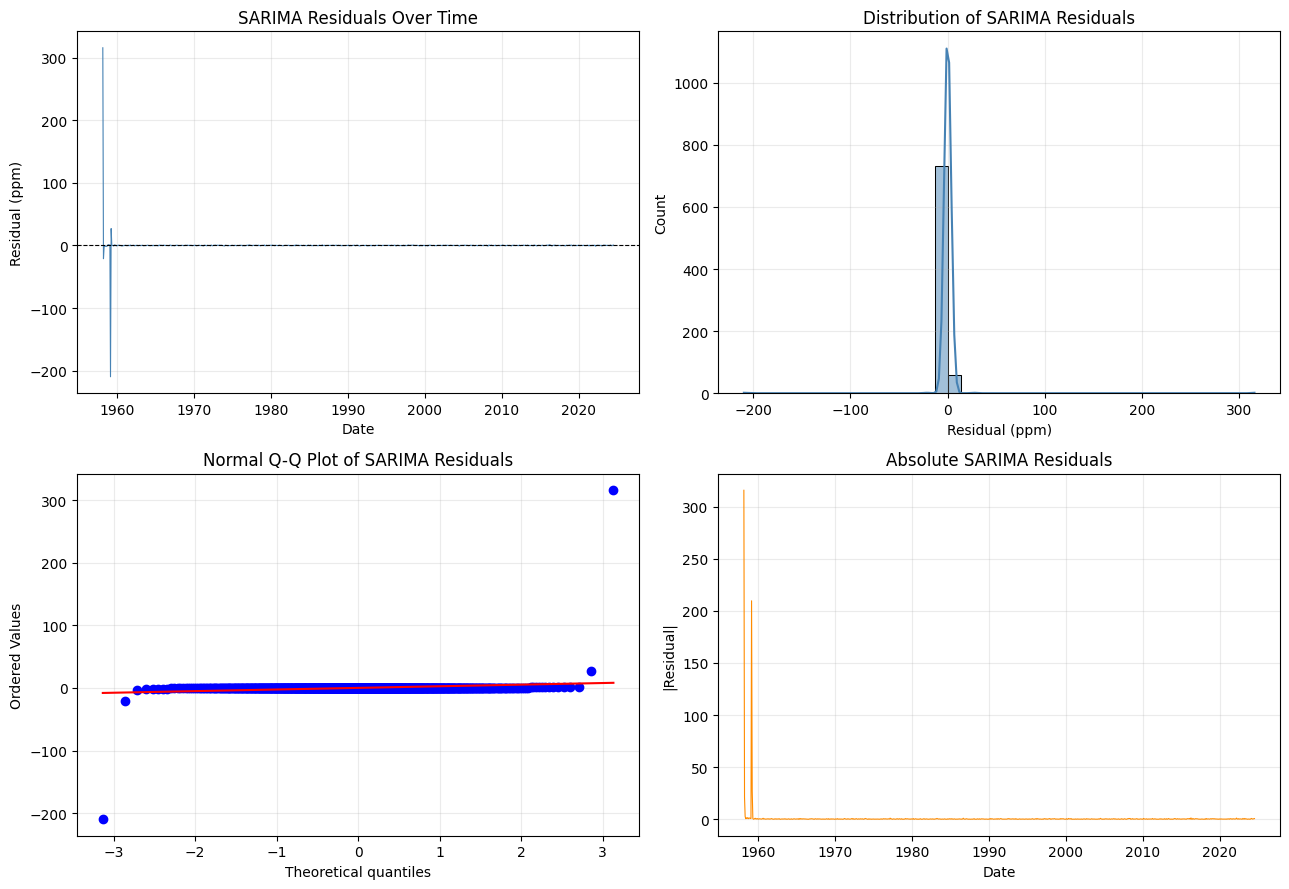

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

residuals = results.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals over time
axes[0, 0].plot(residuals, color="steelblue", linewidth=0.8)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("SARIMA Residuals Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residual (ppm)")
axes[0, 0].grid(alpha=0.25)

# 2. Histogram
sns.histplot(
    residuals,
    bins=40,
    kde=True,
    ax=axes[0, 1],
    color="steelblue"
)
axes[0, 1].set_title("Distribution of SARIMA Residuals")
axes[0, 1].set_xlabel("Residual (ppm)")
axes[0, 1].grid(alpha=0.25)

# 3. Q-Q plot
stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1, 0]
)
axes[1, 0].set_title("Normal Q-Q Plot of SARIMA Residuals")
axes[1, 0].grid(alpha=0.25)

# 4. Absolute residuals
axes[1, 1].plot(
    residuals.abs(),
    color="darkorange",
    linewidth=0.8
)
axes[1, 1].set_title("Absolute SARIMA Residuals")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("|Residual|")
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


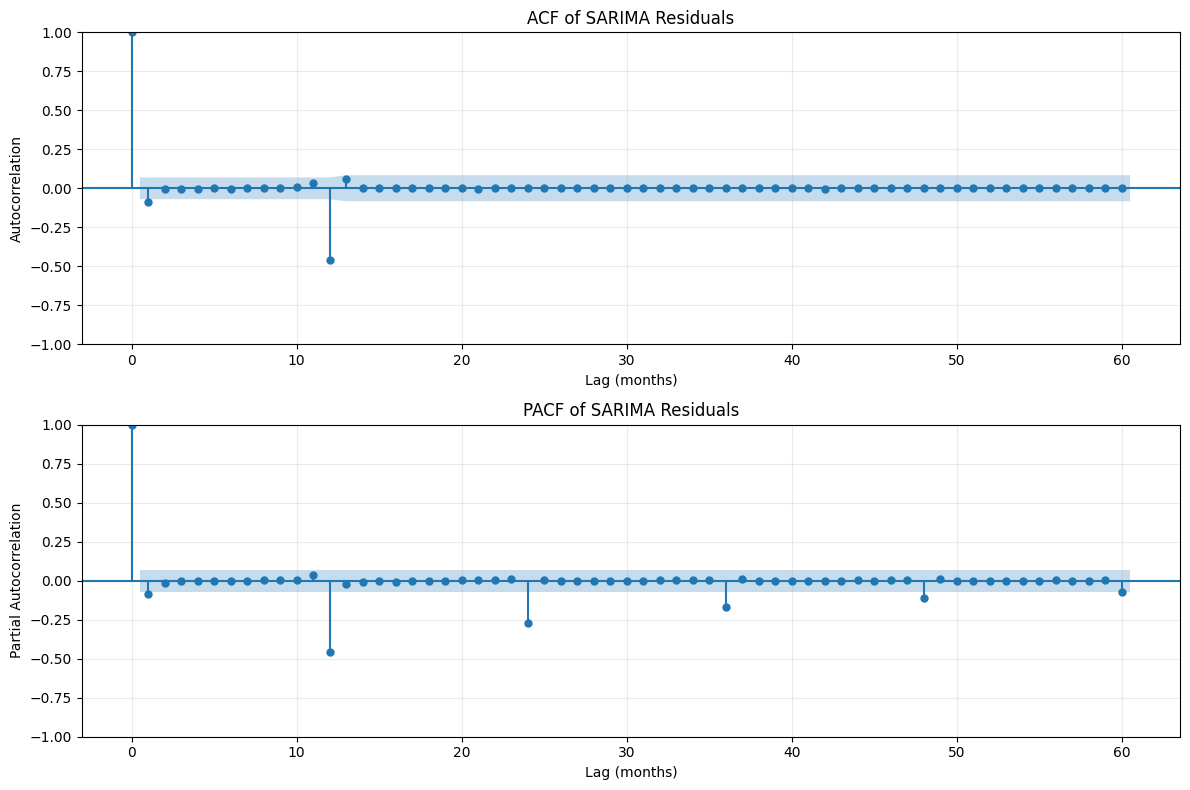

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(
    residuals,
    lags=60,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title("ACF of SARIMA Residuals")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.25)

plot_pacf(
    residuals,
    lags=60,
    ax=axes[1],
    alpha=0.05,
    method="ywm"
)

axes[1].set_title("PACF of SARIMA Residuals")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = results.resid.dropna()

lb = acorr_ljungbox(
    residuals,
    lags=[12, 24, 36],
    return_df=True
)

print(lb)

       lb_stat     lb_pvalue
12  179.491792  5.424320e-32
24  182.268786  2.699764e-26
36  182.276318  1.868081e-21


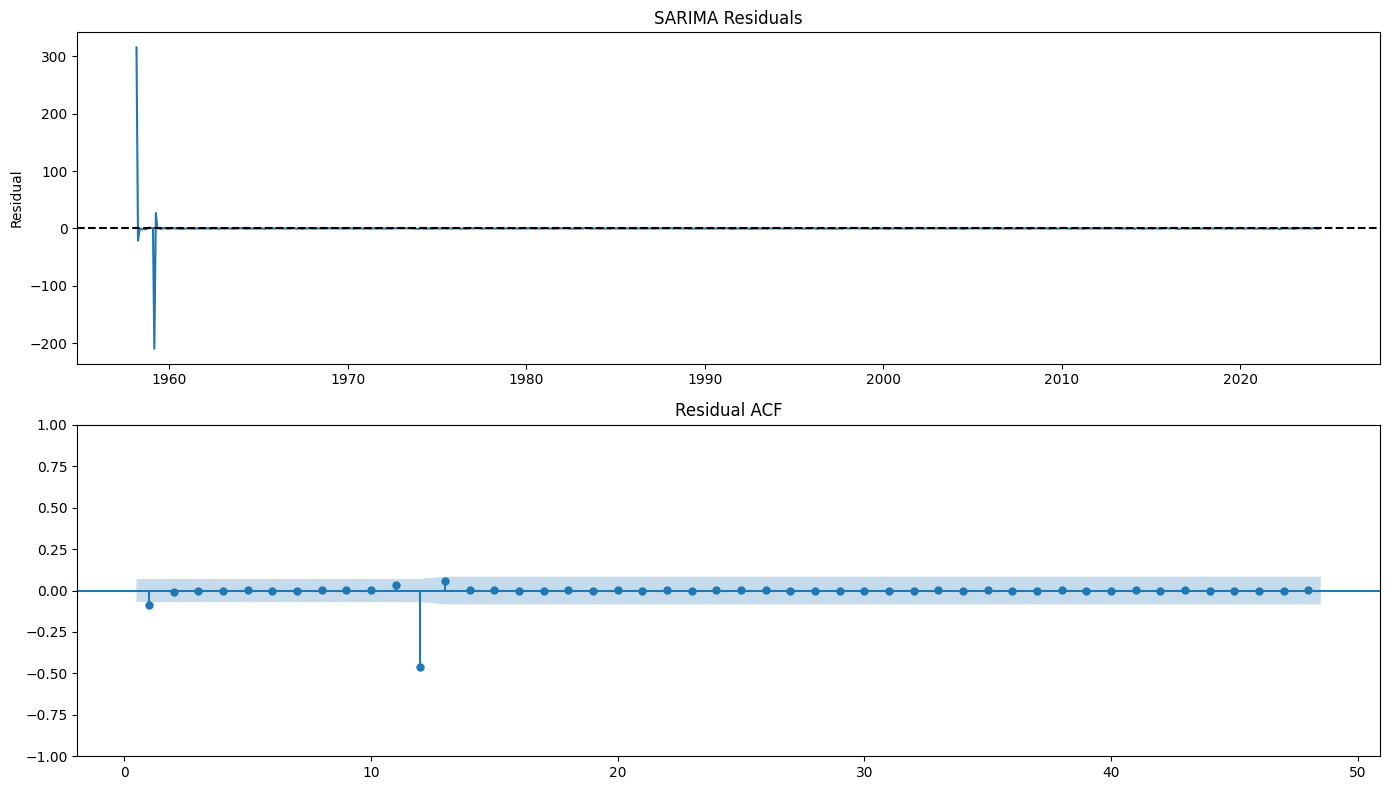

In [6]:
residuals = results.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Residual time series
axes[0].plot(residuals)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("SARIMA Residuals")
axes[0].set_ylabel("Residual")

# Residual ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=48,
    ax=axes[1],
    zero=False
)

axes[1].set_title("Residual ACF")

plt.tight_layout()
plt.show()

In [8]:
# --- 12-month ahead forecast on original scale ---
# Last observed date
last_date = y.index[-1]

# Create forecast index (next 12 months)
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=24,
    freq="MS"
)

# Get forecast and 95% CI
forecast_res = results.get_forecast(steps=24)
mean_forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

mean_forecast.index = forecast_index
conf_int.index = forecast_index

print(mean_forecast)
print(conf_int)


2024-08-01    423.260731
2024-09-01    421.865259
2024-10-01    422.081683
2024-11-01    423.651763
2024-12-01    425.091487
2025-01-01    426.271195
2025-02-01    427.231494
2025-03-01    427.893251
2025-04-01    429.396337
2025-05-01    430.054822
2025-06-01    429.584412
2025-07-01    427.770871
2025-08-01    425.704328
2025-09-01    424.357474
2025-10-01    424.584523
2025-11-01    426.156952
2025-12-01    427.597144
2026-01-01    428.776769
2026-02-01    429.737720
2026-03-01    430.399617
2026-04-01    431.902408
2026-05-01    432.560679
2026-06-01    432.090651
2026-07-01    430.277471
Freq: MS, Name: predicted_mean, dtype: float64
            lower average  upper average
2024-08-01     422.647451     423.874010
2024-09-01     421.135054     422.595465
2024-10-01     421.272304     422.891063
2024-11-01     422.774311     424.529214
2024-12-01     424.151679     426.031294
2025-01-01     425.273083     427.269306
2025-02-01     426.178335     428.284654
2025-03-01     426.787789

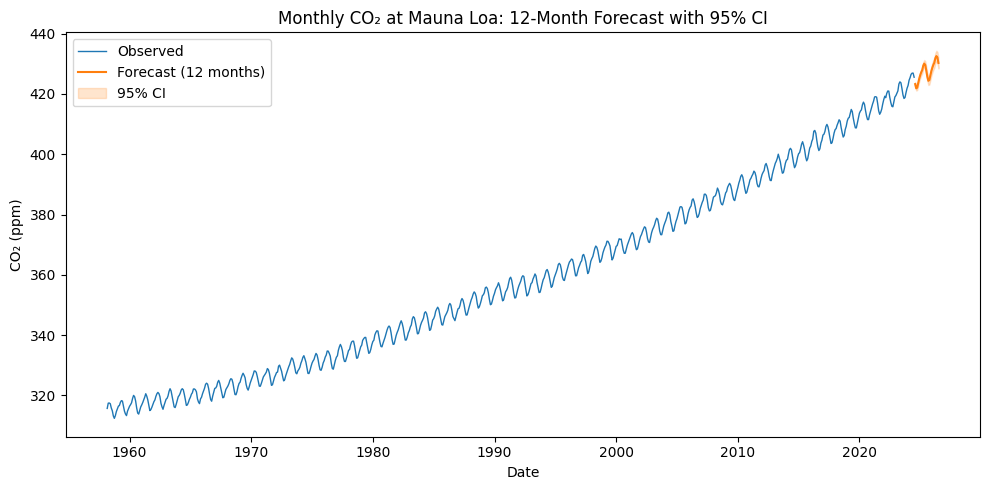

In [9]:
# --- Plot forecast vs raw series with 95% CI ---
plt.figure(figsize=(10, 5))

# Plot historical data
plt.plot(y, label="Observed", linewidth=1)

# Plot forecast
plt.plot(mean_forecast, label="Forecast (12 months)", color="C1")

# Plot confidence intervals
plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="C1",
    alpha=0.2,
    label="95% CI"
)

plt.title("Monthly CO₂ at Mauna Loa: 12-Month Forecast with 95% CI")
plt.xlabel("Date")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.tight_layout()
plt.show()


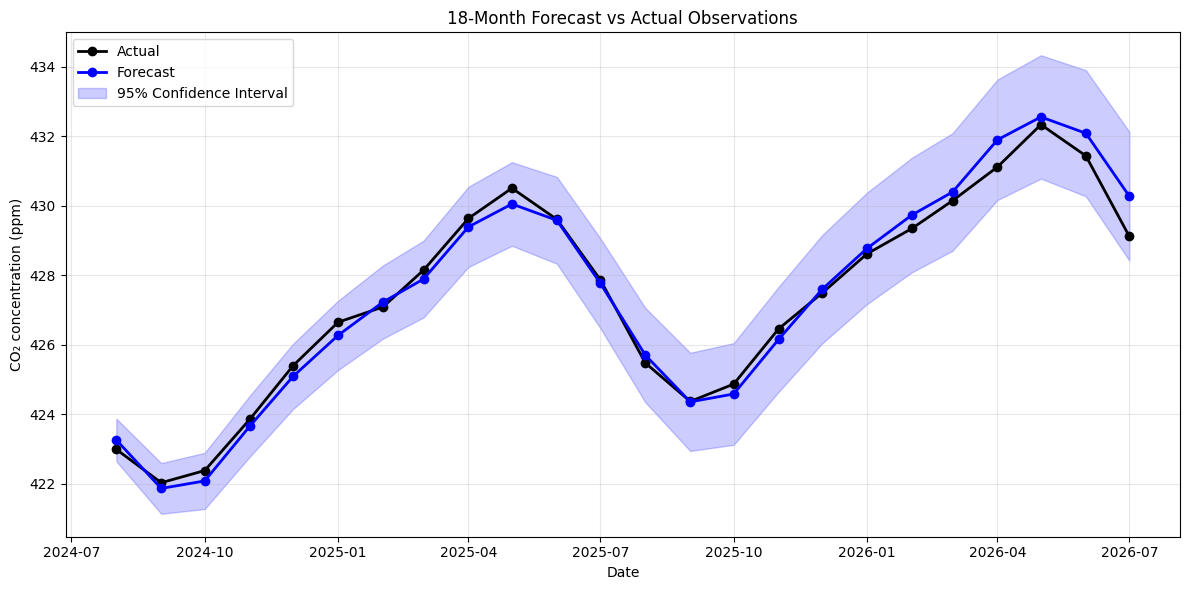

In [10]:
import matplotlib.pyplot as plt

# Actual values from the 18-month holdout period
actual = holdout["average"]

# Plot
plt.figure(figsize=(12, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast vs Actual Observations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    train["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [20]:
forecast_triple = model_triple_fit.forecast(24)
print(forecast_triple)

2024-08-01    423.254670
2024-09-01    421.986435
2024-10-01    422.257875
2024-11-01    423.862820
2024-12-01    425.311840
2025-01-01    426.513323
2025-02-01    427.471348
2025-03-01    428.096802
2025-04-01    429.631510
2025-05-01    430.279984
2025-06-01    429.759875
2025-07-01    427.787962
2025-08-01    425.836612
2025-09-01    424.568377
2025-10-01    424.839817
2025-11-01    426.444762
2025-12-01    427.893782
2026-01-01    429.095265
2026-02-01    430.053291
2026-03-01    430.678744
2026-04-01    432.213452
2026-05-01    432.861927
2026-06-01    432.341817
2026-07-01    430.369904
Freq: MS, dtype: float64


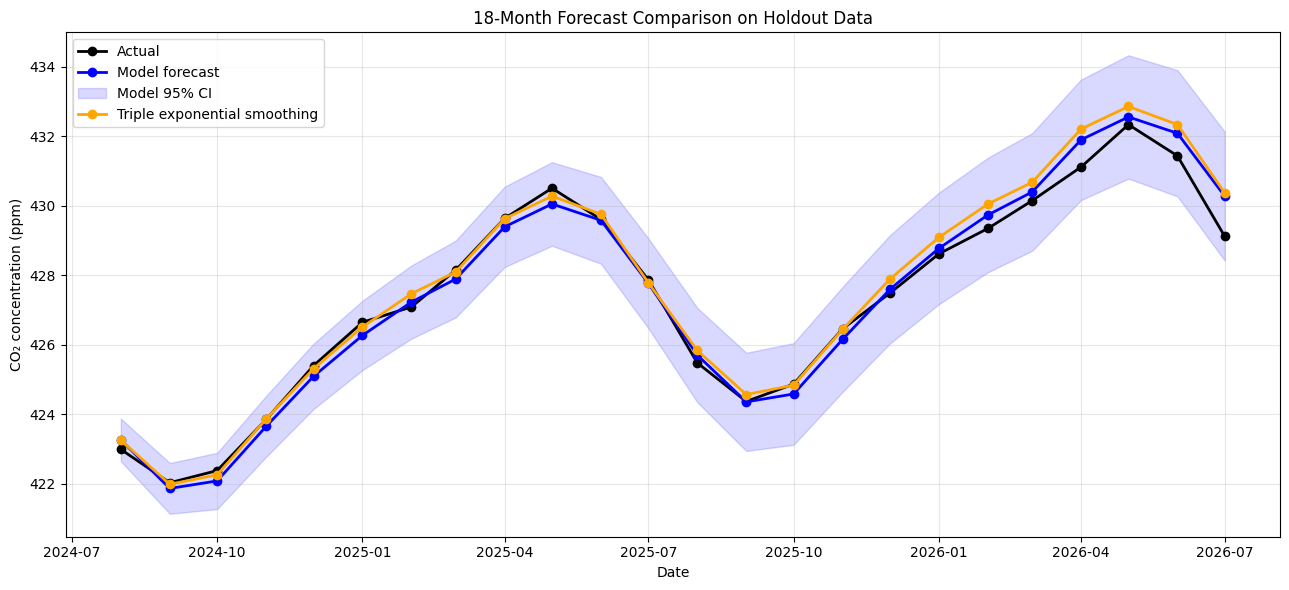

In [21]:
import matplotlib.pyplot as plt

# Actual observations in the 18-month holdout
actual = holdout["average"]

# Triple exponential smoothing forecast
forecast_triple = model_triple_fit.forecast(24)
forecast_triple.index = holdout.index

# Your other model's forecast
# Make sure its index also corresponds to the holdout period
mean_forecast.index = holdout.index
conf_int.index = holdout.index


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model 1 forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Model forecast"
)

# Model 1 95% CI
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.15,
    label="Model 95% CI"
)

# Triple exponential smoothing forecast
plt.plot(
    forecast_triple.index,
    forecast_triple,
    color="orange",
    marker="o",
    linewidth=2,
    label="Triple exponential smoothing"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast Comparison on Holdout Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Actual": holdout["average"],
    "Model_Forecast": mean_forecast,
    "Triple_Exp_Forecast": forecast_triple
})

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast
date                                                   
2024-08-01  422.99      423.260731           423.254670
2024-09-01  422.03      421.865259           421.986435
2024-10-01  422.38      422.081683           422.257875
2024-11-01  423.85      423.651763           423.862820
2024-12-01  425.40      425.091487           425.311840
2025-01-01  426.65      426.271195           426.513323
2025-02-01  427.09      427.231494           427.471348
2025-03-01  428.15      427.893251           428.096802
2025-04-01  429.64      429.396337           429.631510
2025-05-01  430.51      430.054822           430.279984
2025-06-01  429.61      429.584412           429.759875
2025-07-01  427.87      427.770871           427.787962
2025-08-01  425.48      425.704328           425.836612
2025-09-01  424.37      424.357474           424.568377
2025-10-01  424.87      424.584523           424.839817
2025-11-01  426.46      426.156952           426

In [23]:
comparison["Model_Error"] = (
    comparison["Actual"] - comparison["Model_Forecast"]
)

comparison["Triple_Error"] = (
    comparison["Actual"] - comparison["Triple_Exp_Forecast"]
)

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast  Model_Error  \
date                                                                   
2024-08-01  422.99      423.260731           423.254670    -0.270731   
2024-09-01  422.03      421.865259           421.986435     0.164741   
2024-10-01  422.38      422.081683           422.257875     0.298317   
2024-11-01  423.85      423.651763           423.862820     0.198237   
2024-12-01  425.40      425.091487           425.311840     0.308513   
2025-01-01  426.65      426.271195           426.513323     0.378805   
2025-02-01  427.09      427.231494           427.471348    -0.141494   
2025-03-01  428.15      427.893251           428.096802     0.256749   
2025-04-01  429.64      429.396337           429.631510     0.243663   
2025-05-01  430.51      430.054822           430.279984     0.455178   
2025-06-01  429.61      429.584412           429.759875     0.025588   
2025-07-01  427.87      427.770871           427.787962     0.09

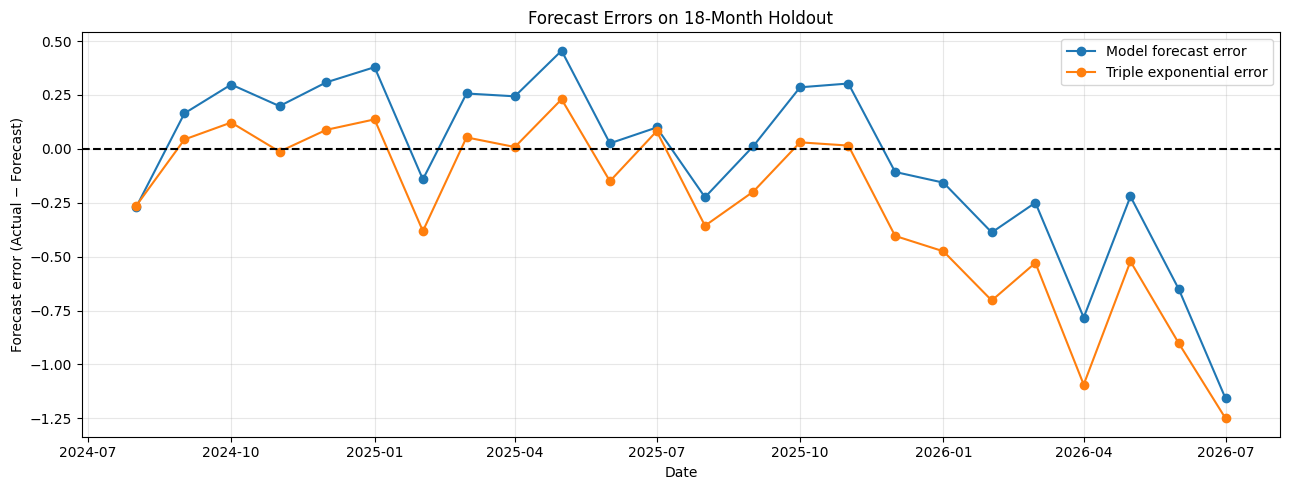

In [24]:
plt.figure(figsize=(13, 5))

plt.plot(
    comparison.index,
    comparison["Model_Error"],
    marker="o",
    label="Model forecast error"
)

plt.plot(
    comparison.index,
    comparison["Triple_Error"],
    marker="o",
    label="Triple exponential error"
)

plt.axhline(0, color="black", linestyle="--")

plt.ylabel("Forecast error (Actual − Forecast)")
plt.xlabel("Date")
plt.title("Forecast Errors on 18-Month Holdout")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(
    comparison["Actual"],
    comparison["Model_Forecast"]
)

mae_triple = mean_absolute_error(
    comparison["Actual"],
    comparison["Triple_Exp_Forecast"]
)

print("Model MAE:", mae_model)
print("Triple exponential MAE:", mae_triple)

Model MAE: 0.30745765214220455
Triple exponential MAE: 0.33548224650475805


In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_model = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Model_Forecast"]
    )
)

rmse_triple = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Triple_Exp_Forecast"]
    )
)

print("Model RMSE:", rmse_model)
print("Triple exponential RMSE:", rmse_triple)

Model RMSE: 0.394061811149464
Triple exponential RMSE: 0.4795075898160414
